In [1]:
# CELL 1: IMPORT LIBRARIES

import os
import random
import shutil
import time
import json
import csv
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
Num GPUs Available: 1


In [2]:
# CELL 2: CHECK HARDWARE

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU is available.")
    for gpu in gpus:
        print(gpu)
else:
    print("WARNING: No GPU detected.")

GPU is available.
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
# CELL 3: REPRODUCIBILITY

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Enable deterministic operations where supported
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
# CELL 4: EXPERIMENT CONFIGURATION

IMG_SIZE = (224, 224)

BATCH_SIZE = 32

INITIAL_EPOCHS = 15
FINE_TUNE_EPOCHS = 10

INITIAL_LEARNING_RATE = 1e-3
FINE_TUNE_LEARNING_RATE = 1e-5

DROPOUT_RATE = 0.30

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Initial epochs:", INITIAL_EPOCHS)
print("Fine-tuning epochs:", FINE_TUNE_EPOCHS)
print("Initial learning rate:", INITIAL_LEARNING_RATE)
print("Fine-tuning learning rate:", FINE_TUNE_LEARNING_RATE)
print("Split:", TRAIN_RATIO, VALIDATION_RATIO, TEST_RATIO)

Image size: (224, 224)
Batch size: 32
Initial epochs: 15
Fine-tuning epochs: 10
Initial learning rate: 0.001
Fine-tuning learning rate: 1e-05
Split: 0.7 0.15 0.15


In [6]:
# CELL 5: MOUNT GOOGLE DRIVE

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# ============================================================
# CELL 6: CREATE PROJECT DIRECTORIES
# ============================================================

PROJECT_DIR = Path("/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0")

DATA_DIR = PROJECT_DIR / "data"
RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models"
CONFIG_DIR = PROJECT_DIR / "configs"

for directory in [
    PROJECT_DIR,
    DATA_DIR,
    RESULTS_DIR,
    MODELS_DIR,
    CONFIG_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directory:")
print(PROJECT_DIR)

Project directory:
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0


In [8]:
# CELL 7: UPLOAD KAGGLE API KEY

from google.colab import files

uploaded = files.upload()

print("Uploaded files:", list(uploaded.keys()))

Saving kaggle.json to kaggle.json
Uploaded files: ['kaggle.json']


In [9]:
# CELL 8: CONFIGURE KAGGLE API

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured.")

Kaggle API configured.


In [10]:
# CELL 9: DOWNLOAD KAGGLE DATASET

!kaggle datasets download -d emmarex/plantdisease -p /content/kaggle_data

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:33<00:00, 20.7MB/s]



In [11]:
# CELL 10: EXTRACT DATASET

import zipfile

zip_files = list(Path("/content/kaggle_data").glob("*.zip"))

print("ZIP files found:")
for z in zip_files:
    print(z)

if not zip_files:
    raise FileNotFoundError("Kaggle dataset ZIP file was not found.")

zip_path = zip_files[0]

extract_path = Path("/content/plantdisease")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:")
print(extract_path)

ZIP files found:
/content/kaggle_data/plantdisease.zip
Dataset extracted to:
/content/plantdisease


In [12]:
# CELL 11: LOCATE PLANTVILLAGE DIRECTORY

plantvillage_dirs = list(extract_path.rglob("PlantVillage"))

print("PlantVillage directories found:")

for directory in plantvillage_dirs:
    print(directory)

if not plantvillage_dirs:
    raise FileNotFoundError(
        "PlantVillage directory was not found. "
        "Please inspect the extracted dataset structure."
    )

PLANTVILLAGE_DIR = plantvillage_dirs[0]

print("\nUsing dataset directory:")
print(PLANTVILLAGE_DIR)

PlantVillage directories found:
/content/plantdisease/PlantVillage
/content/plantdisease/plantvillage/PlantVillage

Using dataset directory:
/content/plantdisease/PlantVillage


In [13]:
# CELL 12: INSPECT DATASET STRUCTURE

class_dirs = sorted([
    d for d in PLANTVILLAGE_DIR.iterdir()
    if d.is_dir()
])

print("Number of class directories:", len(class_dirs))
print("\nClasses:")

for i, class_dir in enumerate(class_dirs):
    print(f"{i:02d}: {class_dir.name}")

Number of class directories: 15

Classes:
00: Pepper__bell___Bacterial_spot
01: Pepper__bell___healthy
02: Potato___Early_blight
03: Potato___Late_blight
04: Potato___healthy
05: Tomato_Bacterial_spot
06: Tomato_Early_blight
07: Tomato_Late_blight
08: Tomato_Leaf_Mold
09: Tomato_Septoria_leaf_spot
10: Tomato_Spider_mites_Two_spotted_spider_mite
11: Tomato__Target_Spot
12: Tomato__Tomato_YellowLeaf__Curl_Virus
13: Tomato__Tomato_mosaic_virus
14: Tomato_healthy


In [14]:
# CELL 14: CLASS DISTRIBUTION

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

class_counts = {}

for class_dir in class_dirs:
    count = sum(
        1
        for file in class_dir.rglob("*")
        if file.suffix.lower() in IMAGE_EXTENSIONS
    )

    class_counts[class_dir.name] = count

class_distribution = (
    pd.DataFrame(
        list(class_counts.items()),
        columns=["Class", "Image_Count"]
    )
    .sort_values("Image_Count", ascending=False)
    .reset_index(drop=True)
)

class_distribution

,Class,Image_Count
0,Tomato__Tomato_YellowLeaf__Curl_Virus,3208
1,Tomato_Bacterial_spot,2127
2,Tomato_Late_blight,1909
3,Tomato_Septoria_leaf_spot,1771
4,Tomato_Spider_mites_Two_spotted_spider_mite,1676
5,Tomato_healthy,1591
6,Pepper__bell___healthy,1478
7,Tomato__Target_Spot,1404
8,Potato___Early_blight,1000
9,Potato___Late_blight,1000


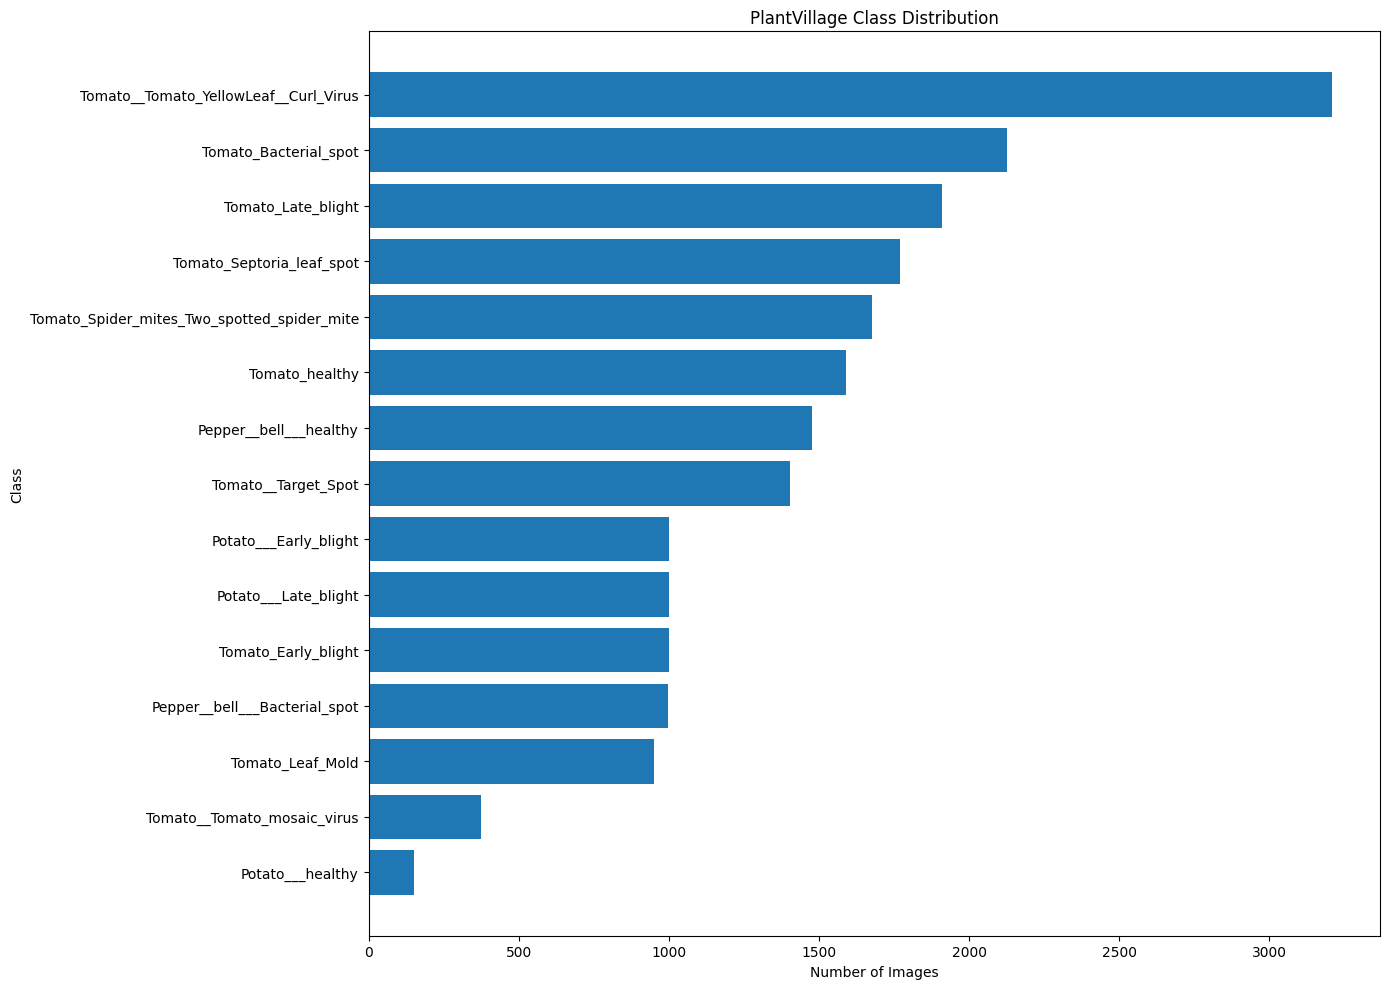

Saved to: /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/class_distribution.png


In [15]:
# CELL 14: PLOT CLASS DISTRIBUTION

plt.figure(figsize=(14, 10))

plt.barh(
    class_distribution["Class"],
    class_distribution["Image_Count"]
)

plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.title("PlantVillage Class Distribution")

plt.gca().invert_yaxis()

plt.tight_layout()

distribution_path = RESULTS_DIR / "class_distribution.png"
plt.savefig(distribution_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", distribution_path)

In [16]:
# CELL 16: CHECK IMAGE PROPERTIES

sample_records = []

for class_dir in class_dirs:
    image_files = [
        f for f in class_dir.rglob("*")
        if f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Check up to 10 images per class
    for image_path in image_files[:10]:
        try:
            with Image.open(image_path) as img:
                sample_records.append({
                    "class": class_dir.name,
                    "width": img.width,
                    "height": img.height,
                    "mode": img.mode,
                    "format": img.format
                })
        except Exception as e:
            print("Error reading:", image_path, e)

image_properties = pd.DataFrame(sample_records)

print(image_properties.head())

print("\nImage modes:")
print(image_properties["mode"].value_counts())

print("\nImage formats:")
print(image_properties["format"].value_counts())

print("\nDimensions:")
print(
    image_properties.groupby(
        ["width", "height"]
    ).size().sort_values(ascending=False).head(20)
)

                           class  width  height mode format
0  Pepper__bell___Bacterial_spot    256     256  RGB   JPEG
1  Pepper__bell___Bacterial_spot    256     256  RGB   JPEG
2  Pepper__bell___Bacterial_spot    256     256  RGB   JPEG
3  Pepper__bell___Bacterial_spot    256     256  RGB   JPEG
4  Pepper__bell___Bacterial_spot    256     256  RGB   JPEG

Image modes:
mode
RGB    150
Name: count, dtype: int64

Image formats:
format
JPEG    150
Name: count, dtype: int64

Dimensions:
width  height
256    256       150
dtype: int64


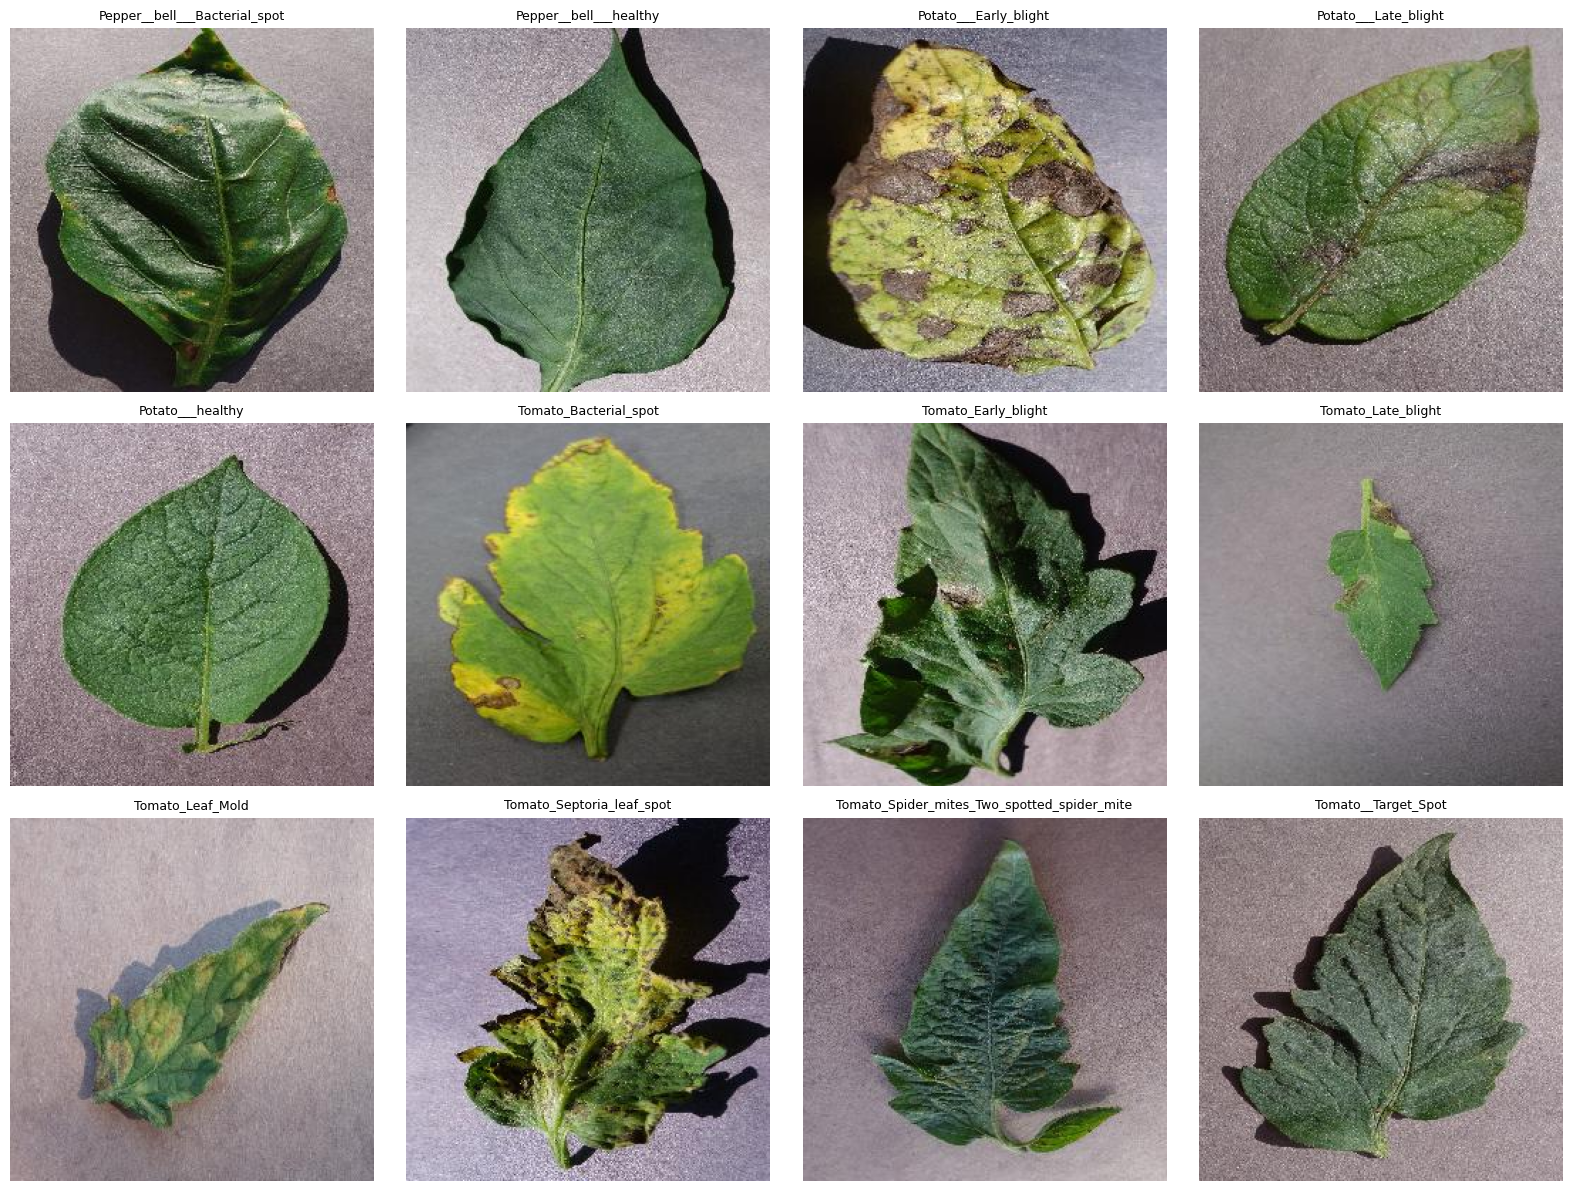

Saved to: /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/sample_images.png


In [17]:
# CELL 17: DISPLAY SAMPLE IMAGES

NUM_CLASSES_TO_DISPLAY = min(12, len(class_dirs))

fig, axes = plt.subplots(
    3,
    4,
    figsize=(16, 12)
)

axes = axes.flatten()

for i, class_dir in enumerate(class_dirs[:NUM_CLASSES_TO_DISPLAY]):

    image_files = [
        f for f in class_dir.rglob("*")
        if f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if not image_files:
        continue

    image_path = random.choice(image_files)

    image = Image.open(image_path).convert("RGB")

    axes[i].imshow(image)
    axes[i].set_title(class_dir.name, fontsize=9)
    axes[i].axis("off")

for j in range(NUM_CLASSES_TO_DISPLAY, len(axes)):
    axes[j].axis("off")

plt.tight_layout()

sample_path = RESULTS_DIR / "sample_images.png"
plt.savefig(sample_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", sample_path)

In [18]:
# CELL 18: CREATE IMAGE DATAFRAME

records = []

class_names = sorted([d.name for d in class_dirs])

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

for class_name in class_names:

    class_dir = PLANTVILLAGE_DIR / class_name

    image_files = [
        f for f in class_dir.rglob("*")
        if f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for image_path in image_files:
        records.append({
            "filepath": str(image_path),
            "class": class_name,
            "label": class_to_index[class_name]
        })

df = pd.DataFrame(records)

print("Total records:", len(df))
print("Number of classes:", df["class"].nunique())

df.head()

Total records: 20638
Number of classes: 15


,filepath,class,label
0,/content/plantdisease/PlantVillage/Pepper__bel...,Pepper__bell___Bacterial_spot,0
1,/content/plantdisease/PlantVillage/Pepper__bel...,Pepper__bell___Bacterial_spot,0
2,/content/plantdisease/PlantVillage/Pepper__bel...,Pepper__bell___Bacterial_spot,0
3,/content/plantdisease/PlantVillage/Pepper__bel...,Pepper__bell___Bacterial_spot,0
4,/content/plantdisease/PlantVillage/Pepper__bel...,Pepper__bell___Bacterial_spot,0


In [19]:
# CELL 19: CHECK FOR CORRUPTED IMAGES

corrupted_files = []

for filepath in df["filepath"]:
    try:
        with Image.open(filepath) as img:
            img.verify()
    except Exception:
        corrupted_files.append(filepath)

print("Corrupted images:", len(corrupted_files))

if corrupted_files:
    print("\nFirst corrupted files:")
    for filepath in corrupted_files[:20]:
        print(filepath)

Corrupted images: 0


In [20]:
# CELL 20: TRAIN / VALIDATION / TEST SPLIT

train_df, temp_df = train_test_split(
    df,
    test_size=(VALIDATION_RATIO + TEST_RATIO),
    stratify=df["label"],
    random_state=SEED
)

relative_test_size = TEST_RATIO / (VALIDATION_RATIO + TEST_RATIO)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

print("\nActual proportions:")
print("Train:", len(train_df) / len(df))
print("Validation:", len(val_df) / len(df))
print("Test:", len(test_df) / len(df))

Training images: 14446
Validation images: 3096
Testing images: 3096

Actual proportions:
Train: 0.6999709274154472
Validation: 0.15001453629227637
Test: 0.15001453629227637


In [21]:
# CELL 21: VERIFY STRATIFIED SPLITS

split_distribution = pd.DataFrame({
    "Train": train_df["class"].value_counts(),
    "Validation": val_df["class"].value_counts(),
    "Test": test_df["class"].value_counts()
}).fillna(0).astype(int)

split_distribution

,Train,Validation,Test
class,,,
Pepper__bell___Bacterial_spot,698,150,149
Pepper__bell___healthy,1035,222,221
Potato___Early_blight,700,150,150
Potato___Late_blight,700,150,150
Potato___healthy,106,23,23
Tomato_Bacterial_spot,1489,319,319
Tomato_Early_blight,700,150,150
Tomato_Late_blight,1336,286,287
Tomato_Leaf_Mold,666,143,143


In [22]:
# CELL 22: SAVE DATA SPLIT

train_df.to_csv(DATA_DIR / "train_split.csv", index=False)
val_df.to_csv(DATA_DIR / "validation_split.csv", index=False)
test_df.to_csv(DATA_DIR / "test_split.csv", index=False)

print("Saved:")
print(DATA_DIR / "train_split.csv")
print(DATA_DIR / "validation_split.csv")
print(DATA_DIR / "test_split.csv")

Saved:
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/data/train_split.csv
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/data/validation_split.csv
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/data/test_split.csv


In [23]:
# CELL 23: CREATE TENSORFLOW DATASETS

AUTOTUNE = tf.data.AUTOTUNE

def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(image, tf.float32)

    return image, label


def create_dataset(dataframe, shuffle=False):

    paths = dataframe["filepath"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = create_dataset(
    train_df,
    shuffle=True
)

validation_dataset = create_dataset(
    val_df,
    shuffle=False
)

test_dataset = create_dataset(
    test_df,
    shuffle=False
)

print("TensorFlow datasets created.")

TensorFlow datasets created.


In [24]:
# CELL 24: DATA AUGMENTATION

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        mode="horizontal"
    ),

    tf.keras.layers.RandomRotation(
        factor=0.05
    ),

    tf.keras.layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),

    tf.keras.layers.RandomContrast(
        factor=0.10
    )
], name="data_augmentation")

print(data_augmentation)

<Sequential name=data_augmentation, built=False>


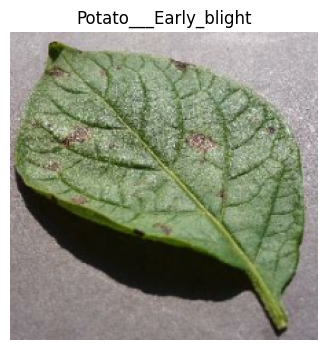

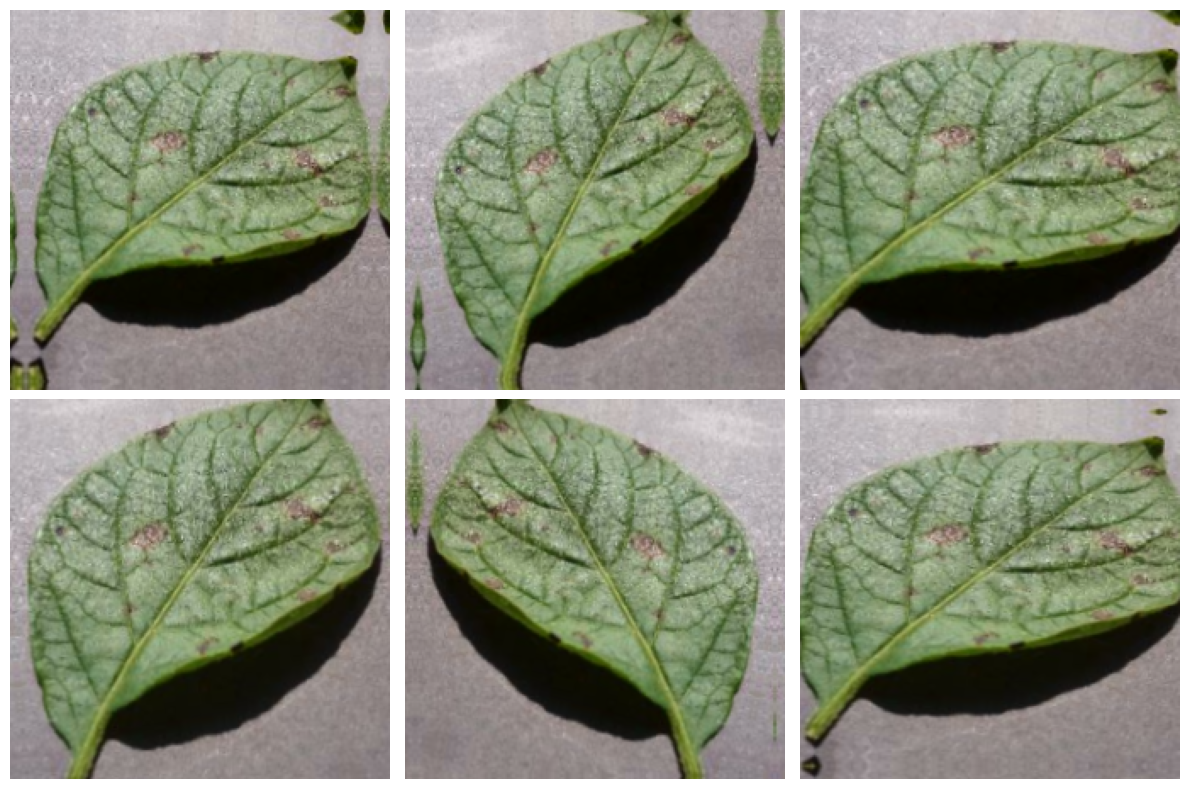

In [27]:
# CELL 25: VISUALIZE DATA AUGMENTATION

sample_images, sample_labels = next(iter(train_dataset))

sample_image = sample_images[0]

plt.figure(figsize=(4, 4))
plt.imshow(
    tf.cast(sample_image, tf.uint8)
)
plt.title(
    class_names[sample_labels[0].numpy()]
)
plt.axis("off")
plt.show()


plt.figure(figsize=(12, 8))

for i in range(6):

    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, axis=0),
        training=True
    )[0]

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        tf.clip_by_value(
            augmented_image / 255.0,
            0,
            1
        )
    )

    plt.axis("off")

plt.tight_layout()
plt.show()